In [1]:
from pathlib import Path
from time import perf_counter
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from sklearn.datasets import fetch_covtype
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from torch import nn
from torch.utils.data import DataLoader, TensorDataset


RANDOM_SEED = 2026

np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

DEVICE = "cuda"

lab_dir = Path.cwd() / "EVAL" / "lab_5"
data_dir = lab_dir / "data"
output_dir = lab_dir / "results"

data_dir.mkdir(parents=True, exist_ok=True)
output_dir.mkdir(parents=True, exist_ok=True)

CONFIG = {
    "expert_val_size": 15000,
    "test_size": 0.20,
    "val_size": 0.20,
    "batch_size": 2048,
    "predict_batch_size": 4096,
    "expert_epochs": 10,
    "learning_rate": 0.005,
    "population_size": 36,
    "generations": 50,
    "elite_count": 4,
    "mutation_rate": 0.70,
    "model_penalty": 0.003,
}

print("Устройство:", DEVICE)
print("PyTorch:", torch.__version__)
print("CUDA доступна:", torch.cuda.is_available())
print("Видеокарта:", torch.cuda.get_device_name(0))

Устройство: cuda
PyTorch: 2.12.0+cu126
CUDA доступна: True
Видеокарта: NVIDIA GeForce RTX 2060


In [2]:
start_load = perf_counter()

covtype = fetch_covtype(
    data_home=str(data_dir),
    download_if_missing=True,
    as_frame=False
)

X = covtype.data.astype(np.float32)
y = covtype.target.astype(np.int64) - 1

load_time = perf_counter() - start_load

N_SAMPLES = X.shape[0]
N_FEATURES = X.shape[1]
N_CLASSES = len(np.unique(y))

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=CONFIG["test_size"],
    random_state=RANDOM_SEED,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=CONFIG["val_size"],
    random_state=RANDOM_SEED,
    stratify=y_train_full
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train).astype(np.float32)
X_val = scaler.transform(X_val).astype(np.float32)
X_test = scaler.transform(X_test).astype(np.float32)

X_expert_train = X_train
y_expert_train = y_train

X_expert_val, _, y_expert_val, _ = train_test_split(
    X_val,
    y_val,
    train_size=CONFIG["expert_val_size"],
    random_state=RANDOM_SEED,
    stratify=y_val
)

print("Размер полного датасета:", X.shape)
print("Количество признаков:", N_FEATURES)
print("Количество классов:", N_CLASSES)
print("Время загрузки, с:", round(load_time, 2))

print()
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

print()
print("Обучающая выборка для экспертов:", X_expert_train.shape)
print("Выборка для генетического алгоритма:", X_expert_val.shape)

print()
print("Распределение классов:")
display(pd.Series(y).value_counts().sort_index())

Размер полного датасета: (581012, 54)
Количество признаков: 54
Количество классов: 7
Время загрузки, с: 0.4

Train: (371847, 54)
Validation: (92962, 54)
Test: (116203, 54)

Обучающая выборка для экспертов: (371847, 54)
Выборка для генетического алгоритма: (15000, 54)

Распределение классов:


0    211840
1    283301
2     35754
3      2747
4      9493
5     17367
6     20510
Name: count, dtype: int64

In [3]:
def make_loader(X_data, y_data, batch_size, shuffle):
    dataset = TensorDataset(
        torch.tensor(X_data, dtype=torch.float32),
        torch.tensor(y_data, dtype=torch.long)
    )
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)
    return loader


class ExpertNet(nn.Module):
    def __init__(self, hidden_layers, activation_name, dropout):
        super().__init__()
        
        activation_layers = {
            "relu": nn.ReLU(),
            "tanh": nn.Tanh(),
            "sigmoid": nn.Sigmoid(),
            "elu": nn.ELU()
        }
        
        layers = []
        input_size = N_FEATURES
        
        for hidden_size in hidden_layers:
            layers.append(nn.Linear(input_size, hidden_size))
            layers.append(activation_layers[activation_name])
            layers.append(nn.Dropout(dropout))
            input_size = hidden_size
        
        layers.append(nn.Linear(input_size, N_CLASSES))
        
        self.net = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.net(x)


def predict_model(model, X_data):
    model.eval()
    predictions = []
    
    with torch.no_grad():
        for start in range(0, len(X_data), CONFIG["predict_batch_size"]):
            batch = torch.tensor(
                X_data[start:start + CONFIG["predict_batch_size"]],
                dtype=torch.float32,
                device=DEVICE
            )
            logits = model(batch)
            batch_predictions = torch.argmax(logits, dim=1).cpu().numpy()
            predictions.append(batch_predictions)
    
    return np.concatenate(predictions)


def count_parameters(model):
    return sum(parameter.numel() for parameter in model.parameters())

In [4]:
import copy

CONFIG["expert_epochs"] = 10

expert_configs = [
    {
        "name": "Модель №1",
        "comment": "простая неглубокая ReLU-сеть",
        "hidden_layers": [64],
        "activation": "relu",
        "dropout": 0.10,
        "l2": 1e-4
    },
    {
        "name": "Модель №2",
        "comment": "средняя ReLU-сеть",
        "hidden_layers": [128, 64],
        "activation": "relu",
        "dropout": 0.20,
        "l2": 1e-4
    },
    {
        "name": "Модель №3",
        "comment": "сеть с tanh-активацией",
        "hidden_layers": [96, 96],
        "activation": "tanh",
        "dropout": 0.15,
        "l2": 5e-4
    },
    {
        "name": "Модель №4",
        "comment": "сеть с ELU-активацией",
        "hidden_layers": [160, 80],
        "activation": "elu",
        "dropout": 0.20,
        "l2": 1e-5
    },
    {
        "name": "Модель №5",
        "comment": "более глубокая ReLU-сеть с сильной регуляризацией",
        "hidden_layers": [128, 128, 64],
        "activation": "relu",
        "dropout": 0.25,
        "l2": 1e-3
    },
    {
        "name": "Модель №6",
        "comment": "лучшая архитектура из лабораторной №4",
        "hidden_layers": [256, 128],
        "activation": "relu",
        "dropout": 0.10,
        "l2": 1e-4
    },
    {
        "name": "Модель №7",
        "comment": "вариант лучшей архитектуры без dropout",
        "hidden_layers": [256, 128],
        "activation": "relu",
        "dropout": 0.00,
        "l2": 1e-5
    },
    {
        "name": "Модель №8",
        "comment": "вариант лучшей архитектуры с ELU-активацией",
        "hidden_layers": [256, 128],
        "activation": "elu",
        "dropout": 0.10,
        "l2": 1e-4
    },
    {
        "name": "Модель №9",
        "comment": "усиленная ReLU-сеть, близкая к лучшей архитектуре",
        "hidden_layers": [320, 160],
        "activation": "relu",
        "dropout": 0.10,
        "l2": 1e-4
    },
    {
        "name": "Модель №10",
        "comment": "более глубокий вариант лучшей архитектуры",
        "hidden_layers": [256, 128, 64],
        "activation": "relu",
        "dropout": 0.15,
        "l2": 5e-4
    }
]


def train_expert(config):
    """
    Обучает одну модель-эксперт на полной train-выборке.
    Возвращает состояние лучшей эпохи по accuracy на валидационной подвыборке.
    """
    model = ExpertNet(
        hidden_layers=config["hidden_layers"],
        activation_name=config["activation"],
        dropout=config["dropout"]
    ).to(DEVICE)

    train_loader = make_loader(
        X_expert_train,
        y_expert_train,
        CONFIG["batch_size"],
        True
    )

    class_counts = np.bincount(y_expert_train, minlength=N_CLASSES).astype(np.float32)
    class_weights = class_counts.sum() / class_counts
    class_weights = class_weights / class_weights.mean()
    class_weights = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)

    criterion = nn.CrossEntropyLoss(weight=class_weights)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=CONFIG["learning_rate"],
        weight_decay=config["l2"]
    )

    epoch_states = []
    epoch_accuracies = []

    for epoch in range(CONFIG["expert_epochs"]):
        model.train()
        epoch_loss = 0

        for batch_x, batch_y in train_loader:
            batch_x = batch_x.to(DEVICE)
            batch_y = batch_y.to(DEVICE)

            optimizer.zero_grad()
            logits = model(batch_x)
            loss = criterion(logits, batch_y)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        val_predictions = predict_model(model, X_expert_val)
        val_accuracy = accuracy_score(y_expert_val, val_predictions)

        epoch_states.append(copy.deepcopy(model.state_dict()))
        epoch_accuracies.append(val_accuracy)

        print(
            config["name"],
            "эпоха",
            epoch + 1,
            "loss:",
            round(epoch_loss, 3),
            "val accuracy:",
            round(val_accuracy, 4)
        )

    best_epoch_index = int(np.argmax(epoch_accuracies))
    model.load_state_dict(epoch_states[best_epoch_index])

    final_predictions = predict_model(model, X_expert_val)
    final_accuracy = accuracy_score(y_expert_val, final_predictions)

    result = {
        "name": config["name"],
        "comment": config["comment"],
        "hidden_layers": config["hidden_layers"],
        "activation": config["activation"],
        "dropout": config["dropout"],
        "l2": config["l2"],
        "best_epoch": best_epoch_index + 1,
        "accuracy": final_accuracy,
        "params": count_parameters(model)
    }

    print(
        "Лучшая эпоха для",
        config["name"] + ":",
        best_epoch_index + 1,
        "accuracy:",
        round(final_accuracy, 4)
    )

    return model, result


expert_models = []
expert_results = []

for config in expert_configs:
    print()
    print("Обучение:", config["name"])
    print("Описание:", config["comment"])

    model, result = train_expert(config)

    expert_models.append(model)
    expert_results.append(result)

expert_results_df = pd.DataFrame(expert_results)

print()
print("Итоговая таблица экспертов:")
display(expert_results_df)


Обучение: Модель №1
Описание: простая неглубокая ReLU-сеть
Модель №1 эпоха 1 loss: 155.262 val accuracy: 0.593
Модель №1 эпоха 2 loss: 117.398 val accuracy: 0.6521
Модель №1 эпоха 3 loss: 108.999 val accuracy: 0.6607
Модель №1 эпоха 4 loss: 103.515 val accuracy: 0.6704
Модель №1 эпоха 5 loss: 100.819 val accuracy: 0.6685
Модель №1 эпоха 6 loss: 97.47 val accuracy: 0.6757
Модель №1 эпоха 7 loss: 95.849 val accuracy: 0.6927
Модель №1 эпоха 8 loss: 94.285 val accuracy: 0.6807
Модель №1 эпоха 9 loss: 92.677 val accuracy: 0.6952
Модель №1 эпоха 10 loss: 91.53 val accuracy: 0.6949
Лучшая эпоха для Модель №1: 9 accuracy: 0.6952

Обучение: Модель №2
Описание: средняя ReLU-сеть
Модель №2 эпоха 1 loss: 148.342 val accuracy: 0.6369
Модель №2 эпоха 2 loss: 114.507 val accuracy: 0.6519
Модель №2 эпоха 3 loss: 106.583 val accuracy: 0.6662
Модель №2 эпоха 4 loss: 101.298 val accuracy: 0.6627
Модель №2 эпоха 5 loss: 97.981 val accuracy: 0.6768
Модель №2 эпоха 6 loss: 94.724 val accuracy: 0.6935
Модел

,name,comment,hidden_layers,activation,dropout,l2,best_epoch,accuracy,params
0,Модель №1,простая неглубокая ReLU-сеть,[64],relu,0.10,0.00010,9,0.695200,3975
1,Модель №2,средняя ReLU-сеть,"[128, 64]",relu,0.20,0.00010,10,0.718933,15751
2,Модель №3,сеть с tanh-активацией,"[96, 96]",tanh,0.15,0.00050,5,0.697867,15271
3,Модель №4,сеть с ELU-активацией,"[160, 80]",elu,0.20,0.00001,9,0.707267,22247
4,Модель №5,более глубокая ReLU-сеть с сильной регуляризацией,"[128, 128, 64]",relu,0.25,0.00100,10,0.690400,32263
5,Модель №6,лучшая архитектура из лабораторной №4,"[256, 128]",relu,0.10,0.00010,9,0.786200,47879
6,Модель №7,вариант лучшей архитектуры без dropout,"[256, 128]",relu,0.00,0.00001,10,0.830200,47879
7,Модель №8,вариант лучшей архитектуры с ELU-активацией,"[256, 128]",elu,0.10,0.00010,10,0.735200,47879
8,Модель №9,"усиленная ReLU-сеть, близкая к лучшей архитектуре","[320, 160]",relu,0.10,0.00010,10,0.783133,70087
9,Модель №10,более глубокий вариант лучшей архитектуры,"[256, 128, 64]",relu,0.15,0.00050,7,0.735267,55687


In [5]:
def predict_proba_model(model, X_data):
    """
    Возвращает вероятности классов для одной модели.
    Используется для последующего усреднения ответов экспертов в ансамбле.
    """
    model.eval()
    probabilities = []

    with torch.no_grad():
        for start in range(0, len(X_data), CONFIG["predict_batch_size"]):
            batch = torch.tensor(
                X_data[start:start + CONFIG["predict_batch_size"]],
                dtype=torch.float32,
                device=DEVICE
            )

            logits = model(batch)
            batch_probabilities = torch.softmax(logits, dim=1).cpu().numpy()
            probabilities.append(batch_probabilities)

    return np.vstack(probabilities)


expert_val_probabilities = []
expert_val_predictions = []

for model_index, model in enumerate(expert_models):
    probabilities = predict_proba_model(model, X_expert_val)
    predictions = np.argmax(probabilities, axis=1)
    accuracy = accuracy_score(y_expert_val, predictions)

    expert_val_probabilities.append(probabilities)
    expert_val_predictions.append(predictions)

    print(
        expert_configs[model_index]["name"],
        "accuracy:",
        round(accuracy, 4)
    )


expert_val_probabilities = np.array(expert_val_probabilities)
expert_val_predictions = np.array(expert_val_predictions).T

average_probabilities = np.mean(expert_val_probabilities, axis=0)
average_predictions = np.argmax(average_probabilities, axis=1)
average_accuracy = accuracy_score(y_expert_val, average_predictions)

best_single_model_index = int(expert_results_df["accuracy"].idxmax())
best_single_name = expert_results_df.loc[best_single_model_index, "name"]
best_single_accuracy = expert_results_df.loc[best_single_model_index, "accuracy"]

print()
print("Размер массива вероятностей:", expert_val_probabilities.shape)
print("Размер массива предсказаний:", expert_val_predictions.shape)

print()
print("Лучшая одиночная модель:", best_single_name)
print("Accuracy лучшей одиночной модели:", round(best_single_accuracy, 4))

print()
print("Accuracy простого усреднения всех экспертов:", round(average_accuracy, 4))

preview_predictions = pd.DataFrame(
    expert_val_predictions[:10],
    columns=[config["name"] for config in expert_configs]
)

display(preview_predictions)

Модель №1 accuracy: 0.6952
Модель №2 accuracy: 0.7189
Модель №3 accuracy: 0.6979
Модель №4 accuracy: 0.7073
Модель №5 accuracy: 0.6904
Модель №6 accuracy: 0.7862
Модель №7 accuracy: 0.8302
Модель №8 accuracy: 0.7352
Модель №9 accuracy: 0.7831
Модель №10 accuracy: 0.7353

Размер массива вероятностей: (10, 15000, 7)
Размер массива предсказаний: (15000, 10)

Лучшая одиночная модель: Модель №7
Accuracy лучшей одиночной модели: 0.8302

Accuracy простого усреднения всех экспертов: 0.7649


,Модель №1,Модель №2,Модель №3,Модель №4,Модель №5,Модель №6,Модель №7,Модель №8,Модель №9,Модель №10
0,0,0,0,0,0,0,0,0,0,0
1,6,6,0,6,6,0,0,0,0,0
2,1,0,1,0,0,0,0,0,0,0
3,1,1,1,1,0,1,1,1,1,1
4,5,5,5,5,5,5,5,5,5,5
5,1,1,1,1,1,1,1,0,1,0
6,1,1,1,1,0,1,1,1,1,1
7,1,1,1,1,1,1,1,1,1,1
8,1,1,1,1,1,1,1,1,1,1
9,6,6,0,6,6,6,6,6,6,6


In [6]:
from dataclasses import dataclass


MODEL_COUNT = len(expert_models)
ZONE_COUNT = 4
FEATURE_NAMES = [f"X{i}" for i in range(N_FEATURES)]


@dataclass
class EnsembleIndividual:
    """
    Особь Smart Ensemble.
    Описывает активные модели, два признака, два порога и группы моделей для 4 зон данных.
    """
    active_models: np.ndarray
    feature_1: int
    threshold_1: float
    feature_2: int
    threshold_2: float
    zone_masks: np.ndarray
    fitness: float = 0.0
    accuracy: float = 0.0
    active_count: int = 0


def make_model_mask():
    """
    Создает случайный бинарный вектор активных моделей.
    """
    count = random.randint(1, MODEL_COUNT)
    selected = random.sample(range(MODEL_COUNT), count)
    mask = np.zeros(MODEL_COUNT, dtype=bool)
    mask[selected] = True
    return mask


def make_zone_masks(active_models):
    """
    Для каждой из 4 зон выбирает непустую группу моделей из активного состава.
    """
    zone_masks = []
    active_indices = list(np.flatnonzero(active_models))

    for _ in range(ZONE_COUNT):
        count = random.randint(1, len(active_indices))
        selected = random.sample(active_indices, count)
        mask = np.zeros(MODEL_COUNT, dtype=bool)
        mask[selected] = True
        zone_masks.append(mask)

    return np.array(zone_masks)


def random_threshold(feature_index):
    """
    Создает случайный порог для признака на основе квантилей.
    """
    low = np.quantile(X_expert_val[:, feature_index], 0.20)
    high = np.quantile(X_expert_val[:, feature_index], 0.80)
    return random.uniform(low, high)


def random_individual():
    """
    Создает случайную стратегию управления ансамблем.
    """
    active_models = make_model_mask()
    feature_1 = random.randrange(N_FEATURES)
    feature_2 = random.randrange(N_FEATURES)

    individual = EnsembleIndividual(
        active_models=active_models,
        feature_1=feature_1,
        threshold_1=random_threshold(feature_1),
        feature_2=feature_2,
        threshold_2=random_threshold(feature_2),
        zone_masks=make_zone_masks(active_models)
    )

    return individual


def get_zones(individual, X_data):
    """
    Делит объекты на 4 зоны по двум признакам и двум порогам.
    """
    high_1 = X_data[:, individual.feature_1] > individual.threshold_1
    high_2 = X_data[:, individual.feature_2] > individual.threshold_2

    zones = high_1.astype(int) + 2 * high_2.astype(int)

    return zones


def predict_ensemble(individual, X_data, expert_probabilities):
    """
    Делает предсказание ансамбля.
    В каждой зоне усредняются вероятности выбранной группы моделей.
    """
    zones = get_zones(individual, X_data)
    final_probabilities = np.zeros((len(X_data), N_CLASSES))

    for zone_id in range(ZONE_COUNT):
        object_mask = zones == zone_id
        model_mask = individual.zone_masks[zone_id]

        selected_probabilities = expert_probabilities[model_mask][:, object_mask, :]
        final_probabilities[object_mask] = selected_probabilities.mean(axis=0)

    predictions = np.argmax(final_probabilities, axis=1)

    return predictions


def evaluate_individual(individual):
    """
    Считает fitness особи.
    Fitness = Accuracy - штраф за число активных моделей.
    """
    predictions = predict_ensemble(
        individual,
        X_expert_val,
        expert_val_probabilities
    )

    accuracy = accuracy_score(y_expert_val, predictions)
    active_count = int(individual.active_models.sum())
    fitness = accuracy - CONFIG["model_penalty"] * active_count

    individual.accuracy = accuracy
    individual.active_count = active_count
    individual.fitness = fitness

    return individual


test_individual = evaluate_individual(random_individual())

print("Пример случайной особи")
print("Активных моделей:", test_individual.active_count)

print()
print("Признак 1:", FEATURE_NAMES[test_individual.feature_1])
print("Порог 1:", round(test_individual.threshold_1, 4))

print()
print("Признак 2:", FEATURE_NAMES[test_individual.feature_2])
print("Порог 2:", round(test_individual.threshold_2, 4))

print()
print("Accuracy:", round(test_individual.accuracy, 4))
print("Fitness:", round(test_individual.fitness, 4))

print()
print("Группы моделей по зонам:")

for zone_id in range(ZONE_COUNT):
    model_numbers = np.flatnonzero(test_individual.zone_masks[zone_id]) + 1
    print("Зона", zone_id, "- модели", list(model_numbers))

Пример случайной особи
Активных моделей: 2

Признак 1: X32
Порог 1: -0.0836

Признак 2: X41
Порог 2: -0.0396

Accuracy: 0.783
Fitness: 0.777

Группы моделей по зонам:
Зона 0 - модели [np.int64(9)]
Зона 1 - модели [np.int64(6), np.int64(9)]
Зона 2 - модели [np.int64(6)]
Зона 3 - модели [np.int64(9)]


In [7]:
from itertools import combinations

CONFIG["model_penalty"] = 0.002
CONFIG["population_size"] = 36
CONFIG["generations"] = 50
CONFIG["mutation_rate"] = 0.70


def clone_individual(individual):
    """
    Создает независимую копию особи Smart Ensemble.
    """
    return EnsembleIndividual(
        active_models=individual.active_models.copy(),
        feature_1=individual.feature_1,
        threshold_1=individual.threshold_1,
        feature_2=individual.feature_2,
        threshold_2=individual.threshold_2,
        zone_masks=individual.zone_masks.copy(),
        fitness=individual.fitness,
        accuracy=individual.accuracy,
        active_count=individual.active_count
    )


def refresh_active_models(individual):
    """
    Обновляет список активных моделей по маскам зон.
    """
    individual.active_models = individual.zone_masks.any(axis=0)
    return individual


def make_candidate_model_masks():
    """
    Создает варианты групп моделей для зоны.
    Рассматриваются одиночные модели, пары моделей и тройки моделей.
    """
    masks = []

    for group_size in [1, 2, 3]:
        for model_indices in combinations(range(MODEL_COUNT), group_size):
            mask = np.zeros(MODEL_COUNT, dtype=bool)
            mask[list(model_indices)] = True
            masks.append(mask)

    return masks


candidate_model_masks = make_candidate_model_masks()


def best_mask_for_zone(object_mask):
    """
    Подбирает лучшую группу моделей для одной зоны данных.
    """
    best_score = -1
    best_mask = candidate_model_masks[0]

    for model_mask in candidate_model_masks:
        zone_probabilities = expert_val_probabilities[model_mask][:, object_mask, :].mean(axis=0)
        zone_predictions = np.argmax(zone_probabilities, axis=1)
        score = accuracy_score(y_expert_val[object_mask], zone_predictions)

        if score > best_score:
            best_score = score
            best_mask = model_mask.copy()

    return best_mask


def optimize_zone_masks(individual):
    """
    Для заданных признаков и порогов подбирает лучшие группы моделей в каждой из 4 зон.
    """
    zones = get_zones(individual, X_expert_val)
    zone_masks = []

    for zone_id in range(ZONE_COUNT):
        object_mask = zones == zone_id

        if object_mask.sum() == 0:
            zone_masks.append(candidate_model_masks[0].copy())
        else:
            zone_masks.append(best_mask_for_zone(object_mask))

    individual.zone_masks = np.array(zone_masks)
    individual = refresh_active_models(individual)

    return individual


def make_rule_individual(feature_1, threshold_1, feature_2, threshold_2):
    """
    Создает стратегию с заданными признаками и порогами.
    Группы моделей для зон подбираются отдельно.
    """
    empty_zone_masks = np.zeros((ZONE_COUNT, MODEL_COUNT), dtype=bool)

    individual = EnsembleIndividual(
        active_models=np.zeros(MODEL_COUNT, dtype=bool),
        feature_1=feature_1,
        threshold_1=threshold_1,
        feature_2=feature_2,
        threshold_2=threshold_2,
        zone_masks=empty_zone_masks
    )

    individual = optimize_zone_masks(individual)
    individual = evaluate_individual(individual)

    return individual


def make_fixed_strategy(model_indices):
    """
    Создает стратегию, где во всех зонах используется один и тот же набор моделей.
    """
    mask = np.zeros(MODEL_COUNT, dtype=bool)
    mask[model_indices] = True

    zone_masks = np.array([mask.copy() for _ in range(ZONE_COUNT)])

    individual = EnsembleIndividual(
        active_models=mask.copy(),
        feature_1=0,
        threshold_1=random_threshold(0),
        feature_2=1,
        threshold_2=random_threshold(1),
        zone_masks=zone_masks
    )

    individual = evaluate_individual(individual)

    return individual


def make_random_rule_individual():
    """
    Создает случайную стратегию и оптимизирует группы моделей внутри ее зон.
    """
    feature_1 = random.randrange(N_FEATURES)
    feature_2 = random.randrange(N_FEATURES)

    return make_rule_individual(
        feature_1=feature_1,
        threshold_1=random_threshold(feature_1),
        feature_2=feature_2,
        threshold_2=random_threshold(feature_2)
    )


def tournament_selection(population):
    """
    Выбирает родителя через турнирный отбор.
    """
    candidates = random.sample(population, 3)
    return clone_individual(max(candidates, key=lambda item: item.fitness))


def crossover_individual(parent_a, parent_b):
    """
    Создает потомка из двух родителей.
    """
    feature_1 = random.choice([parent_a.feature_1, parent_b.feature_1])
    feature_2 = random.choice([parent_a.feature_2, parent_b.feature_2])
    threshold_1 = random.choice([parent_a.threshold_1, parent_b.threshold_1])
    threshold_2 = random.choice([parent_a.threshold_2, parent_b.threshold_2])

    child = make_rule_individual(
        feature_1=feature_1,
        threshold_1=threshold_1,
        feature_2=feature_2,
        threshold_2=threshold_2
    )

    return child


def mutate_individual(individual):
    """
    Случайно изменяет признак или порог стратегии.
    """
    result = clone_individual(individual)
    mutation_type = random.choice([
        "feature_1",
        "feature_2",
        "threshold_1",
        "threshold_2",
        "full_reset"
    ])

    if mutation_type == "feature_1":
        result.feature_1 = random.randrange(N_FEATURES)
        result.threshold_1 = random_threshold(result.feature_1)

    elif mutation_type == "feature_2":
        result.feature_2 = random.randrange(N_FEATURES)
        result.threshold_2 = random_threshold(result.feature_2)

    elif mutation_type == "threshold_1":
        result.threshold_1 = random_threshold(result.feature_1)

    elif mutation_type == "threshold_2":
        result.threshold_2 = random_threshold(result.feature_2)

    elif mutation_type == "full_reset":
        result = make_random_rule_individual()

    result = optimize_zone_masks(result)
    result = evaluate_individual(result)

    return result


def make_initial_population():
    """
    Создает начальную популяцию из базовых и случайных стратегий.
    """
    population = []

    for model_index in range(MODEL_COUNT):
        population.append(make_fixed_strategy([model_index]))

    population.append(make_fixed_strategy(list(range(MODEL_COUNT))))

    best_model_index = int(expert_results_df["accuracy"].idxmax())

    for model_index in range(MODEL_COUNT):
        pair = sorted(list(set([best_model_index, model_index])))
        population.append(make_fixed_strategy(pair))

    while len(population) < CONFIG["population_size"]:
        population.append(make_random_rule_individual())

    population = sorted(population, key=lambda item: item.fitness, reverse=True)

    return population[:CONFIG["population_size"]]


def run_genetic_algorithm():
    """
    Запускает генетический алгоритм поиска стратегии Smart Ensemble.
    """
    population = make_initial_population()
    history = []

    for generation in range(1, CONFIG["generations"] + 1):
        population = sorted(population, key=lambda item: item.fitness, reverse=True)
        best = population[0]

        history.append({
            "generation": generation,
            "best_accuracy": best.accuracy,
            "best_fitness": best.fitness,
            "active_count": best.active_count,
            "feature_1": best.feature_1,
            "feature_2": best.feature_2
        })

        print(
            "Поколение",
            generation,
            "| accuracy:",
            round(best.accuracy, 4),
            "| fitness:",
            round(best.fitness, 4),
            "| активных моделей:",
            best.active_count
        )

        next_population = [clone_individual(item) for item in population[:CONFIG["elite_count"]]]

        while len(next_population) < CONFIG["population_size"]:
            parent_a = tournament_selection(population)
            parent_b = tournament_selection(population)

            child = crossover_individual(parent_a, parent_b)

            if random.random() < CONFIG["mutation_rate"]:
                child = mutate_individual(child)

            next_population.append(child)

        population = next_population

    population = sorted(population, key=lambda item: item.fitness, reverse=True)
    genetic_history_df = pd.DataFrame(history)

    return population[0], genetic_history_df


genetic_start = perf_counter()

best_ensemble, genetic_history_df = run_genetic_algorithm()

genetic_time = perf_counter() - genetic_start

print()
print("Лучшая найденная стратегия Smart Ensemble")
print("Accuracy:", round(best_ensemble.accuracy, 4))
print("Fitness:", round(best_ensemble.fitness, 4))
print("Активных моделей:", best_ensemble.active_count)
print("Время работы генетического алгоритма, с:", round(genetic_time, 2))

Поколение 1 | accuracy: 0.8302 | fitness: 0.8282 | активных моделей: 1
Поколение 2 | accuracy: 0.8366 | fitness: 0.8326 | активных моделей: 2
Поколение 3 | accuracy: 0.8366 | fitness: 0.8326 | активных моделей: 2
Поколение 4 | accuracy: 0.8366 | fitness: 0.8326 | активных моделей: 2
Поколение 5 | accuracy: 0.8366 | fitness: 0.8326 | активных моделей: 2
Поколение 6 | accuracy: 0.8366 | fitness: 0.8326 | активных моделей: 2
Поколение 7 | accuracy: 0.8366 | fitness: 0.8326 | активных моделей: 2
Поколение 8 | accuracy: 0.8366 | fitness: 0.8326 | активных моделей: 2
Поколение 9 | accuracy: 0.8366 | fitness: 0.8326 | активных моделей: 2
Поколение 10 | accuracy: 0.8366 | fitness: 0.8326 | активных моделей: 2
Поколение 11 | accuracy: 0.8366 | fitness: 0.8326 | активных моделей: 2
Поколение 12 | accuracy: 0.8366 | fitness: 0.8326 | активных моделей: 2
Поколение 13 | accuracy: 0.8367 | fitness: 0.8327 | активных моделей: 2
Поколение 14 | accuracy: 0.8367 | fitness: 0.8327 | активных моделей: 2
П

In [8]:
best_ensemble_predictions = predict_ensemble(
    best_ensemble,
    X_expert_val,
    expert_val_probabilities
)

best_ensemble_zones = get_zones(best_ensemble, X_expert_val)

zone_conditions = [
    f"{FEATURE_NAMES[best_ensemble.feature_1]} <= {best_ensemble.threshold_1:.4f} и {FEATURE_NAMES[best_ensemble.feature_2]} <= {best_ensemble.threshold_2:.4f}",
    f"{FEATURE_NAMES[best_ensemble.feature_1]} > {best_ensemble.threshold_1:.4f} и {FEATURE_NAMES[best_ensemble.feature_2]} <= {best_ensemble.threshold_2:.4f}",
    f"{FEATURE_NAMES[best_ensemble.feature_1]} <= {best_ensemble.threshold_1:.4f} и {FEATURE_NAMES[best_ensemble.feature_2]} > {best_ensemble.threshold_2:.4f}",
    f"{FEATURE_NAMES[best_ensemble.feature_1]} > {best_ensemble.threshold_1:.4f} и {FEATURE_NAMES[best_ensemble.feature_2]} > {best_ensemble.threshold_2:.4f}",
]

zone_rows = []

for zone_id in range(ZONE_COUNT):
    object_mask = best_ensemble_zones == zone_id
    model_numbers = [int(index + 1) for index in np.flatnonzero(best_ensemble.zone_masks[zone_id])]
    zone_accuracy = accuracy_score(y_expert_val[object_mask], best_ensemble_predictions[object_mask])

    zone_rows.append({
        "Зона": zone_id,
        "Условие": zone_conditions[zone_id],
        "Количество объектов": int(object_mask.sum()),
        "Доля объектов": round(float(object_mask.mean()), 4),
        "Модели в зоне": model_numbers,
        "Accuracy зоны": round(zone_accuracy, 4)
    })

zone_rules_df = pd.DataFrame(zone_rows)

active_model_numbers = [int(index + 1) for index in np.flatnonzero(best_ensemble.active_models)]

print("Итоговая стратегия Smart Ensemble")
print()
print("Accuracy ансамбля:", round(best_ensemble.accuracy, 4))
print("Fitness ансамбля:", round(best_ensemble.fitness, 4))
print("Активных моделей:", best_ensemble.active_count)
print("Список активных моделей:", active_model_numbers)

print()
print("Признак 1:", FEATURE_NAMES[best_ensemble.feature_1])
print("Порог 1:", round(best_ensemble.threshold_1, 4))

print()
print("Признак 2:", FEATURE_NAMES[best_ensemble.feature_2])
print("Порог 2:", round(best_ensemble.threshold_2, 4))

print()
print("Сравнение с лучшей одиночной моделью")
print("Лучшая одиночная модель:", best_single_name)
print("Accuracy лучшей одиночной модели:", round(best_single_accuracy, 4))
print("Прирост Smart Ensemble:", round(best_ensemble.accuracy - best_single_accuracy, 4))

print()
print("Правила переключения по зонам:")
display(zone_rules_df)

Итоговая стратегия Smart Ensemble

Accuracy ансамбля: 0.8375
Fitness ансамбля: 0.8335
Активных моделей: 2
Список активных моделей: [6, 7]

Признак 1: X0
Порог 1: 0.0921

Признак 2: X45
Порог 2: -0.3168

Сравнение с лучшей одиночной моделью
Лучшая одиночная модель: Модель №7
Accuracy лучшей одиночной модели: 0.8302
Прирост Smart Ensemble: 0.0073

Правила переключения по зонам:


,Зона,Условие,Количество объектов,Доля объектов,Модели в зоне,Accuracy зоны
0,0,X0 <= 0.0921 и X45 <= -0.3168,6896,0.4597,[7],0.8256
1,1,X0 > 0.0921 и X45 <= -0.3168,6821,0.4547,"[6, 7]",0.8557
2,2,X0 <= 0.0921 и X45 > -0.3168,308,0.0205,[7],0.7792
3,3,X0 > 0.0921 и X45 > -0.3168,975,0.0650,[7],0.8123


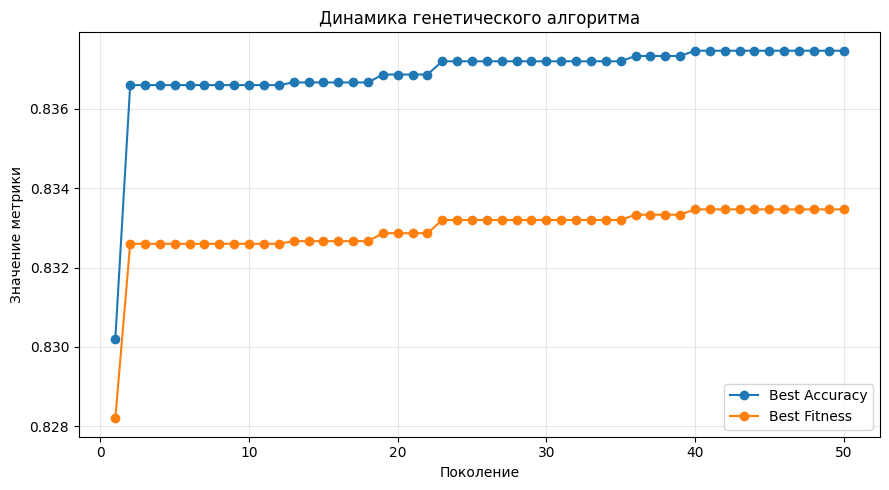

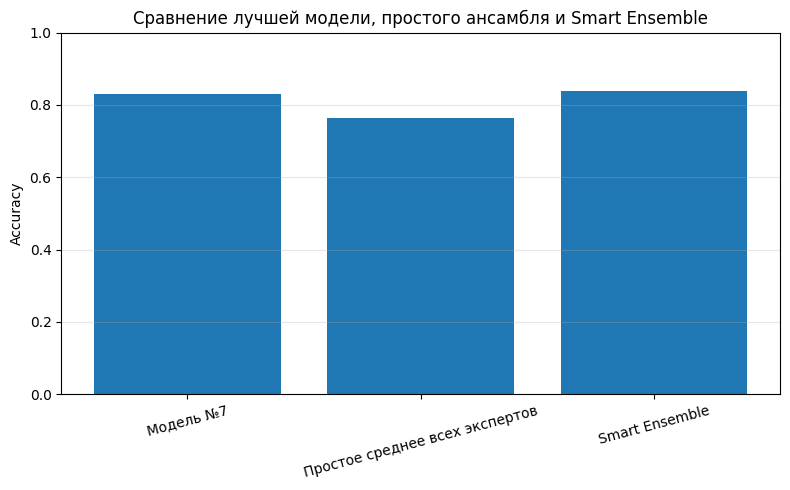

,Метод,Accuracy
0,Модель №7,0.830200
1,Простое среднее всех экспертов,0.764867
2,Smart Ensemble,0.837467


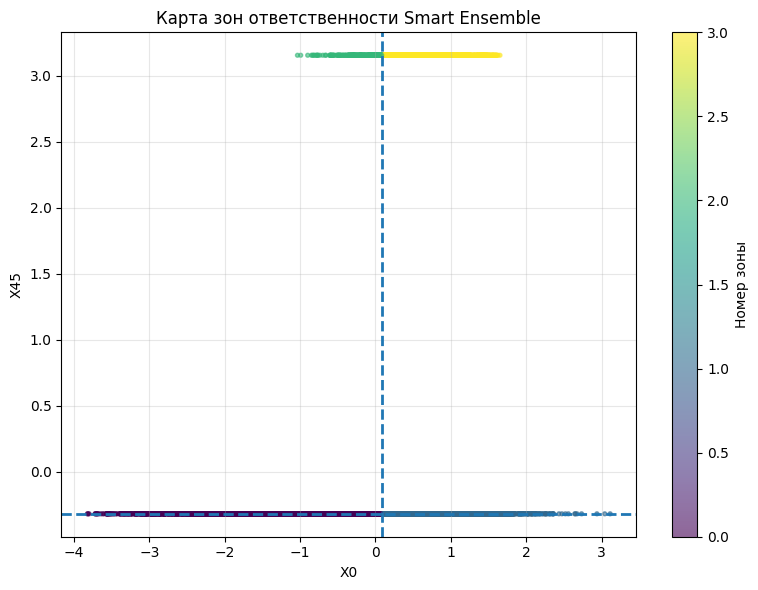

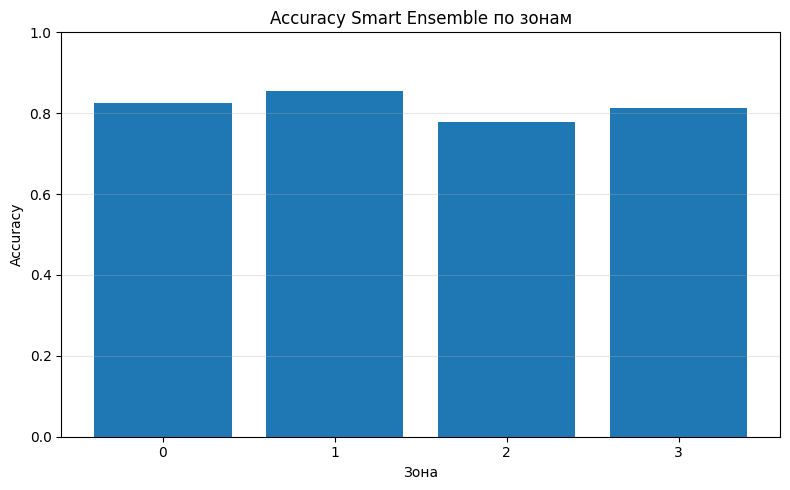

,Зона,Количество объектов,Доля объектов,Модели в зоне,Accuracy зоны
0,0,6896,0.4597,[7],0.8256
1,1,6821,0.4547,"[6, 7]",0.8557
2,2,308,0.0205,[7],0.7792
3,3,975,0.0650,[7],0.8123


In [9]:
plt.figure(figsize=(9, 5))
plt.plot(genetic_history_df["generation"], genetic_history_df["best_accuracy"], marker="o", label="Best Accuracy")
plt.plot(genetic_history_df["generation"], genetic_history_df["best_fitness"], marker="o", label="Best Fitness")
plt.xlabel("Поколение")
plt.ylabel("Значение метрики")
plt.title("Динамика генетического алгоритма")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / "genetic_algorithm_dynamics.png", dpi=160)
plt.show()


comparison_df = pd.DataFrame([
    {
        "Метод": best_single_name,
        "Accuracy": best_single_accuracy
    },
    {
        "Метод": "Простое среднее всех экспертов",
        "Accuracy": average_accuracy
    },
    {
        "Метод": "Smart Ensemble",
        "Accuracy": best_ensemble.accuracy
    }
])

plt.figure(figsize=(8, 5))
plt.bar(comparison_df["Метод"], comparison_df["Accuracy"])
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Сравнение лучшей модели, простого ансамбля и Smart Ensemble")
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(output_dir / "smart_ensemble_comparison.png", dpi=160)
plt.show()

display(comparison_df)


plt.figure(figsize=(8, 6))
plt.scatter(
    X_expert_val[:, best_ensemble.feature_1],
    X_expert_val[:, best_ensemble.feature_2],
    c=best_ensemble_zones,
    s=8,
    alpha=0.6
)
plt.axvline(best_ensemble.threshold_1, linestyle="--", linewidth=2)
plt.axhline(best_ensemble.threshold_2, linestyle="--", linewidth=2)
plt.xlabel(FEATURE_NAMES[best_ensemble.feature_1])
plt.ylabel(FEATURE_NAMES[best_ensemble.feature_2])
plt.title("Карта зон ответственности Smart Ensemble")
plt.colorbar(label="Номер зоны")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(output_dir / "smart_ensemble_decision_map.png", dpi=160)
plt.show()


zone_accuracy_df = zone_rules_df[["Зона", "Количество объектов", "Доля объектов", "Модели в зоне", "Accuracy зоны"]]

plt.figure(figsize=(8, 5))
plt.bar(zone_accuracy_df["Зона"].astype(str), zone_accuracy_df["Accuracy зоны"])
plt.ylim(0, 1)
plt.xlabel("Зона")
plt.ylabel("Accuracy")
plt.title("Accuracy Smart Ensemble по зонам")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(output_dir / "zone_accuracy.png", dpi=160)
plt.show()

display(zone_accuracy_df)

,Зона,Количество объектов,Модели Smart Ensemble,Accuracy Smart Ensemble,Accuracy лучшей одиночной модели,Разница Accuracy,Ансамбль исправил ошибок одиночной модели,Одиночная модель лучше ансамбля,Обе модели ошиблись
0,0,6896,[7],0.825551,0.825551,0.00000,0,0,1203
1,1,6821,"[6, 7]",0.855740,0.839760,0.01598,249,140,844
2,2,308,[7],0.779221,0.779221,0.00000,0,0,68
3,3,975,[7],0.812308,0.812308,0.00000,0,0,183


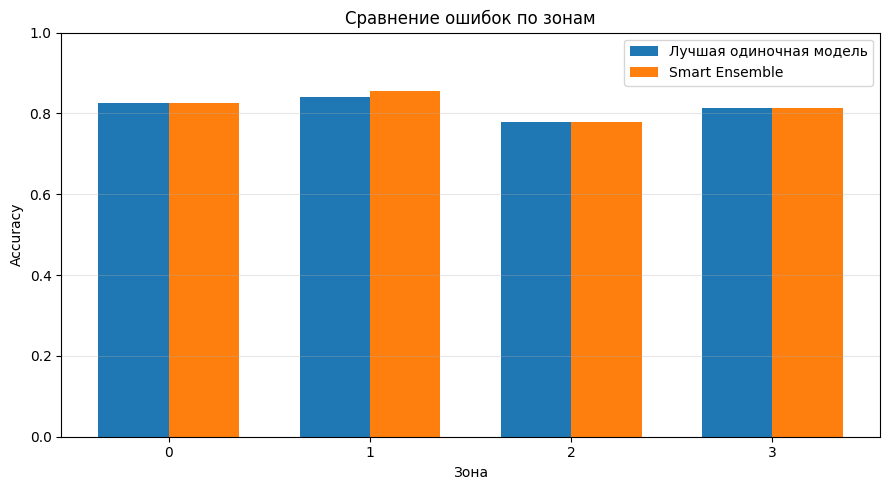

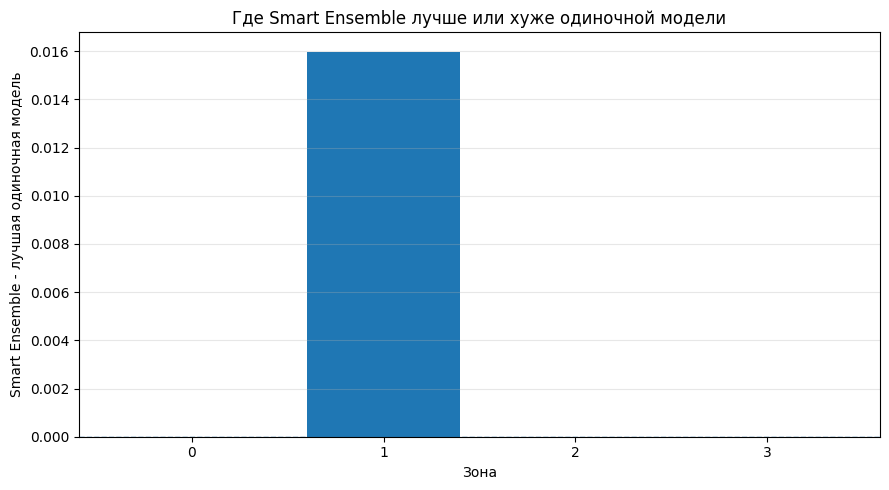

In [10]:
best_single_predictions = expert_val_predictions[:, best_single_model_index]

ensemble_correct = best_ensemble_predictions == y_expert_val
single_correct = best_single_predictions == y_expert_val

error_rows = []

for zone_id in range(ZONE_COUNT):
    object_mask = best_ensemble_zones == zone_id
    
    ensemble_zone_accuracy = accuracy_score(
        y_expert_val[object_mask],
        best_ensemble_predictions[object_mask]
    )
    
    single_zone_accuracy = accuracy_score(
        y_expert_val[object_mask],
        best_single_predictions[object_mask]
    )
    
    ensemble_better_count = int((object_mask & ensemble_correct & ~single_correct).sum())
    single_better_count = int((object_mask & ~ensemble_correct & single_correct).sum())
    both_wrong_count = int((object_mask & ~ensemble_correct & ~single_correct).sum())
    
    error_rows.append({
        "Зона": zone_id,
        "Количество объектов": int(object_mask.sum()),
        "Модели Smart Ensemble": [int(index + 1) for index in np.flatnonzero(best_ensemble.zone_masks[zone_id])],
        "Accuracy Smart Ensemble": ensemble_zone_accuracy,
        "Accuracy лучшей одиночной модели": single_zone_accuracy,
        "Разница Accuracy": ensemble_zone_accuracy - single_zone_accuracy,
        "Ансамбль исправил ошибок одиночной модели": ensemble_better_count,
        "Одиночная модель лучше ансамбля": single_better_count,
        "Обе модели ошиблись": both_wrong_count
    })

error_analysis_df = pd.DataFrame(error_rows)

display(error_analysis_df)


plt.figure(figsize=(9, 5))
x = np.arange(len(error_analysis_df))
width = 0.35

plt.bar(
    x - width / 2,
    error_analysis_df["Accuracy лучшей одиночной модели"],
    width,
    label="Лучшая одиночная модель"
)

plt.bar(
    x + width / 2,
    error_analysis_df["Accuracy Smart Ensemble"],
    width,
    label="Smart Ensemble"
)

plt.xticks(x, error_analysis_df["Зона"])
plt.ylim(0, 1)
plt.xlabel("Зона")
plt.ylabel("Accuracy")
plt.title("Сравнение ошибок по зонам")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / "error_analysis_by_zones.png", dpi=160)
plt.show()


plt.figure(figsize=(9, 5))
plt.bar(
    error_analysis_df["Зона"].astype(str),
    error_analysis_df["Разница Accuracy"]
)
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Зона")
plt.ylabel("Smart Ensemble - лучшая одиночная модель")
plt.title("Где Smart Ensemble лучше или хуже одиночной модели")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(output_dir / "smart_ensemble_accuracy_gain_by_zone.png", dpi=160)
plt.show()